# figure 2 and related figures for appendices and talks

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings(
  "ignore",
  message="Numcodecs codecs are not in the Zarr version 3 specification*",
  category=UserWarning
)

# setup all the imports
import matplotlib.font_manager
import matplotlib.pyplot as plt
import cartopy.crs as ccrs  # noqa: E402
import numpy as np
import seaborn as sns
import pandas as pd
import xarray as xr

flist = matplotlib.font_manager.get_font_names()
from pathlib import Path  # noqa: E402

import extremeweatherbench as ewb

# resolve project root from notebook location (works in VS Code/Cursor),
# falling back to cwd for other environments
try:
    basepath = Path(__vsc_ipynb_file__).parent.parent
except NameError:
    basepath = Path.cwd()
basepath = str(basepath) + "/"

import src.plots.plotting_utils as plot_utils  # noqa: E402
import src.plots.results_utils as results_utils  # noqa: E402
import src.plots.heat_freeze_utils as heat_freeze_utils  # noqa: E402
import src.plots.plotting_styles as ps  # noqa: E402

# load in all of the events in the yaml file
print("loading in the events yaml file")
ewb_cases = ewb.cases.load_ewb_events_yaml_into_case_list()

ewb_cases = [n for n in ewb_cases if n.event_type == "freeze" or n.event_type == "heat_wave"]

# build out all of the expected data to evalate the case
# this will not be a 1-1 mapping with ewb_cases because there are multiple data sources
# to evaluate for some cases
# for example, a heat/cold case will have both a case operator for ERA-5 data and GHCN
case_operators = ewb.cases.build_case_operators(
    ewb_cases, ewb.defaults.get_brightband_evaluation_objects()
)


load_ewb_events_yaml_into_case_list is deprecated. Use load_ewb_events_yaml_into_case_list instead.


loading in the events yaml file


In [3]:
# load the results back in
# heat results
hres_heat_results = pd.read_pickle(basepath + 'saved_data/hres_heat_results.pkl')
bb_pangu_heat_results = pd.read_pickle(basepath + 'saved_data/bb_pangu_heat_results.pkl')
bb_graphcast_heat_results = pd.read_pickle(basepath + 'saved_data/bb_graphcast_heat_results.pkl')
bb_aifs_heat_results = pd.read_pickle(basepath + 'saved_data/bb_aifs_heat_results.pkl')
cira_fourv2_heat_results = pd.read_pickle(basepath + 'saved_data/cira_fourv2_heat_results.pkl')
cira_pangu_heat_results = pd.read_pickle(basepath + 'saved_data/cira_pangu_heat_results.pkl')
cira_graphcast_heat_results = pd.read_pickle(basepath + 'saved_data/cira_graphcast_heat_results.pkl')

# freeze results
hres_freeze_results = pd.read_pickle(basepath + 'saved_data/hres_freeze_results.pkl')
bb_pangu_freeze_results = pd.read_pickle(basepath + 'saved_data/bb_pangu_freeze_results.pkl')
bb_graphcast_freeze_results = pd.read_pickle(basepath + 'saved_data/bb_graphcast_freeze_results.pkl')
bb_aifs_freeze_results = pd.read_pickle(basepath + 'saved_data/bb_aifs_freeze_results.pkl')
cira_fourv2_freeze_results = pd.read_pickle(basepath + 'saved_data/cira_fourv2_freeze_results.pkl')
cira_pangu_freeze_results = pd.read_pickle(basepath + 'saved_data/cira_pangu_freeze_results.pkl')
cira_graphcast_freeze_results = pd.read_pickle(basepath + 'saved_data/cira_graphcast_freeze_results.pkl')

In [4]:
# North America
na_bounding_box = [-172, -45, 7, 85]
na_bounding_box_polygon = plot_utils.get_polygon_from_bounding_box(na_bounding_box)
na_bounding_region = ewb.regions.BoundingBoxRegion(latitude_min=7, latitude_max=85, longitude_min=-172, longitude_max=-45)

# Europe
eu_bounding_box = [50, -15, 15, 75]
eu_bounding_box_polygon = plot_utils.get_polygon_from_bounding_box(eu_bounding_box)
eu_bounding_region = ewb.regions.BoundingBoxRegion(latitude_min=50, latitude_max=75, longitude_min=-15, longitude_max=15)

# break the cases into different lists
na_subset = ewb.regions.RegionSubsetter(region=na_bounding_region, method='intersects').subset_case_list(ewb_cases)
eu_subset = ewb.regions.RegionSubsetter(region=eu_bounding_region, method='intersects').subset_case_list(ewb_cases)

na_case_ids = [n.case_id_number for n in na_subset]
eu_case_ids = [n.case_id_number for n in eu_subset]
print(na_case_ids)
print(eu_case_ids)

[1, 2, 3, 4, 5, 6, 27, 30, 31, 35, 70, 71, 72, 73, 74, 75, 77, 84, 87, 88, 89]
[8, 9, 10, 19, 20, 21, 22, 32, 81, 82, 83, 90, 91, 92, 94]


In [20]:
def get_error_array_for_heatmap(ewb_cases, results_array, hres_results, forecast_sources, 
    target_source, metric_strs, lead_time_days, higher_is_better_list):
    """
    This function takes in an array of results and parameters to say which results to grab and returns 
    error arrays and relative arrays for global, north america, and europe.
    """
    # now make the array for the scorecard
    global_rel_error = {}
    global_error = {}

    na_rel_error = {}
    na_error = {}

    eu_rel_error = {}
    eu_error = {}

    for i, metric in enumerate(metric_strs):
        # initialize the arrays
        global_rel_error[metric] = np.zeros((len(results_array), len(lead_time_days)))
        global_error[metric] = np.zeros((len(results_array), len(lead_time_days)))

        na_rel_error[metric] = np.zeros((len(results_array), len(lead_time_days)))
        na_error[metric] = np.zeros((len(results_array), len(lead_time_days)))

        eu_rel_error[metric] = np.zeros((len(results_array), len(lead_time_days)))
        eu_error[metric] = np.zeros((len(results_array), len(lead_time_days)))

        higher_is_better = higher_is_better_list[i]

        for j, results_df in enumerate(results_array):
            my_mean, my_relative_error = results_utils.compute_relative_error(ewb_cases, results_df, 
                forecast_source=forecast_sources[j], 
                comparison_results_df=hres_results, 
                comparison_forecast_source=ps.hres_settings['forecast_source'], 
                target_source=target_source, 
                metric=metric, lead_time_days=lead_time_days, 
                higher_is_better=higher_is_better)
            global_error[metric][j, :] = my_mean
            global_rel_error[metric][j, :] = my_relative_error

            na_mean, na_relative_error = results_utils.compute_relative_error(ewb_cases, results_df,
                forecast_source=forecast_sources[j], 
                comparison_results_df=hres_results, 
                comparison_forecast_source=ps.hres_settings['forecast_source'], 
                target_source=target_source, 
                metric=metric, lead_time_days=lead_time_days, 
                case_ids=na_case_ids, 
                higher_is_better=higher_is_better)
            na_error[metric][j, :] = na_mean
            na_rel_error[metric][j, :] = na_relative_error

            eu_mean, eu_relative_error = results_utils.compute_relative_error(ewb_cases, results_df,
                forecast_source=forecast_sources[j], 
                comparison_results_df=hres_results, 
                comparison_forecast_source=ps.hres_settings['forecast_source'], 
                target_source=target_source, 
                metric=metric, lead_time_days=lead_time_days, 
                case_ids=eu_case_ids, 
                higher_is_better=higher_is_better)
            eu_error[metric][j, :] = eu_mean
            eu_rel_error[metric][j, :] = eu_relative_error


    return global_error, global_rel_error, na_error, na_rel_error, eu_error, eu_rel_error

# setup for the scorecard
# Grab means for each metric for each model
heat_metric_str = ['MaximumMeanAbsoluteError', 'RootMeanSquaredError', 'MaximumLowestMeanAbsoluteError']
freeze_metric_str = ['MinimumMeanAbsoluteError', 'RootMeanSquaredError']
heat_display_str = ['MAE Max Temp', 'RMSE', 'MAE Highest Min Temp']
freeze_display_str = ['MAE Min Temp', 'RMSE']
heat_metric_higher_is_better = [False, False, False, False]
freeze_metric_higher_is_better = [False, False, False]

lead_time_days = [1, 3, 5, 7, 10]

heat_results_array = [hres_heat_results, bb_graphcast_heat_results, 
    bb_pangu_heat_results, bb_aifs_heat_results]
forecast_source = [ps.hres_ifs_settings['forecast_source'], 
    ps.bb_graphcast_settings['forecast_source'], ps.bb_pangu_settings['forecast_source'], 
    ps.bb_aifs_settings['forecast_source']]
freeze_results_array = [hres_freeze_results, bb_graphcast_freeze_results, 
    bb_pangu_freeze_results, bb_aifs_freeze_results]

(global_heat_error, global_rel_heat_error, na_heat_error, na_rel_heat_error, eu_heat_error, eu_rel_heat_error) = \
    get_error_array_for_heatmap(ewb_cases, heat_results_array, hres_heat_results, 
    forecast_source, 'GHCN', heat_metric_str, lead_time_days, heat_metric_higher_is_better )
(global_freeze_error, global_rel_freeze_error, na_freeze_error, na_rel_freeze_error, eu_freeze_error, eu_rel_freeze_error) = \
    get_error_array_for_heatmap(ewb_cases, freeze_results_array, hres_freeze_results, 
    forecast_source, 'GHCN', freeze_metric_str, lead_time_days, freeze_metric_higher_is_better)

In [6]:
def get_single_case_error_array_for_heatmap(ewb_cases, results_array, hres_results, forecast_sources, 
    target_source, metric_strs, lead_time_days, higher_is_better_list, case_id):
    """
    This function takes in an array of results and parameters to say which results to grab and returns 
    error arrays and relative arrays for global, north america, and europe.
    """
    # now make the array for the scorecard
    rel_error = {}
    error = {}

    for i, metric in enumerate(metric_strs):
        print(metric)

        # initialize the arrays
        rel_error[metric] = np.zeros((len(results_array), len(lead_time_days)))
        error[metric] = np.zeros((len(results_array), len(lead_time_days)))

        higher_is_better = higher_is_better_list[i]

        for j, results_df in enumerate(results_array):
            print(forecast_sources[j])
            my_mean, my_relative_error = results_utils.compute_relative_error(
                ewb_cases=ewb_cases, 
                results_df=results_df, 
                forecast_source=forecast_sources[j], 
                comparison_results_df=hres_results, 
                comparison_forecast_source=ps.hres_settings['forecast_source'], 
                target_source=target_source, 
                metric=metric, lead_time_days=lead_time_days, 
                higher_is_better=higher_is_better, case_ids=[case_id])
            error[metric][j, :] = my_mean
            rel_error[metric][j, :] = my_relative_error

    return error, rel_error

# subset results for the specific cases
my_heat_case_id = 1
my_freeze_case_id = 91
for n in ewb_cases:
    if n.case_id_number == 1:
        my_heat_case = n
    if n.case_id_number == 91:
        my_freeze_case = n

(heat_case_error, heat_case_rel_error) = \
    get_single_case_error_array_for_heatmap(ewb_cases, heat_results_array, hres_heat_results, 
    forecast_source, 'GHCN', heat_metric_str, lead_time_days, 
    heat_metric_higher_is_better, my_heat_case_id)

(freeze_case_error, freeze_case_rel_error) = \
    get_single_case_error_array_for_heatmap(ewb_cases, freeze_results_array, hres_freeze_results, 
    forecast_source, 'GHCN', freeze_metric_str, lead_time_days, 
    freeze_metric_higher_is_better, my_freeze_case_id)


MaximumMeanAbsoluteError
ECMWF HRES
BB graphcast
BB panguweather
BB aifs-single
RootMeanSquaredError
ECMWF HRES
BB graphcast
BB panguweather
BB aifs-single
MaximumLowestMeanAbsoluteError
ECMWF HRES
BB graphcast
BB panguweather
BB aifs-single
MinimumMeanAbsoluteError
ECMWF HRES
BB graphcast
BB panguweather
BB aifs-single
RootMeanSquaredError
ECMWF HRES
BB graphcast
BB panguweather
BB aifs-single


(30, 36)
plotting the cases for each event type


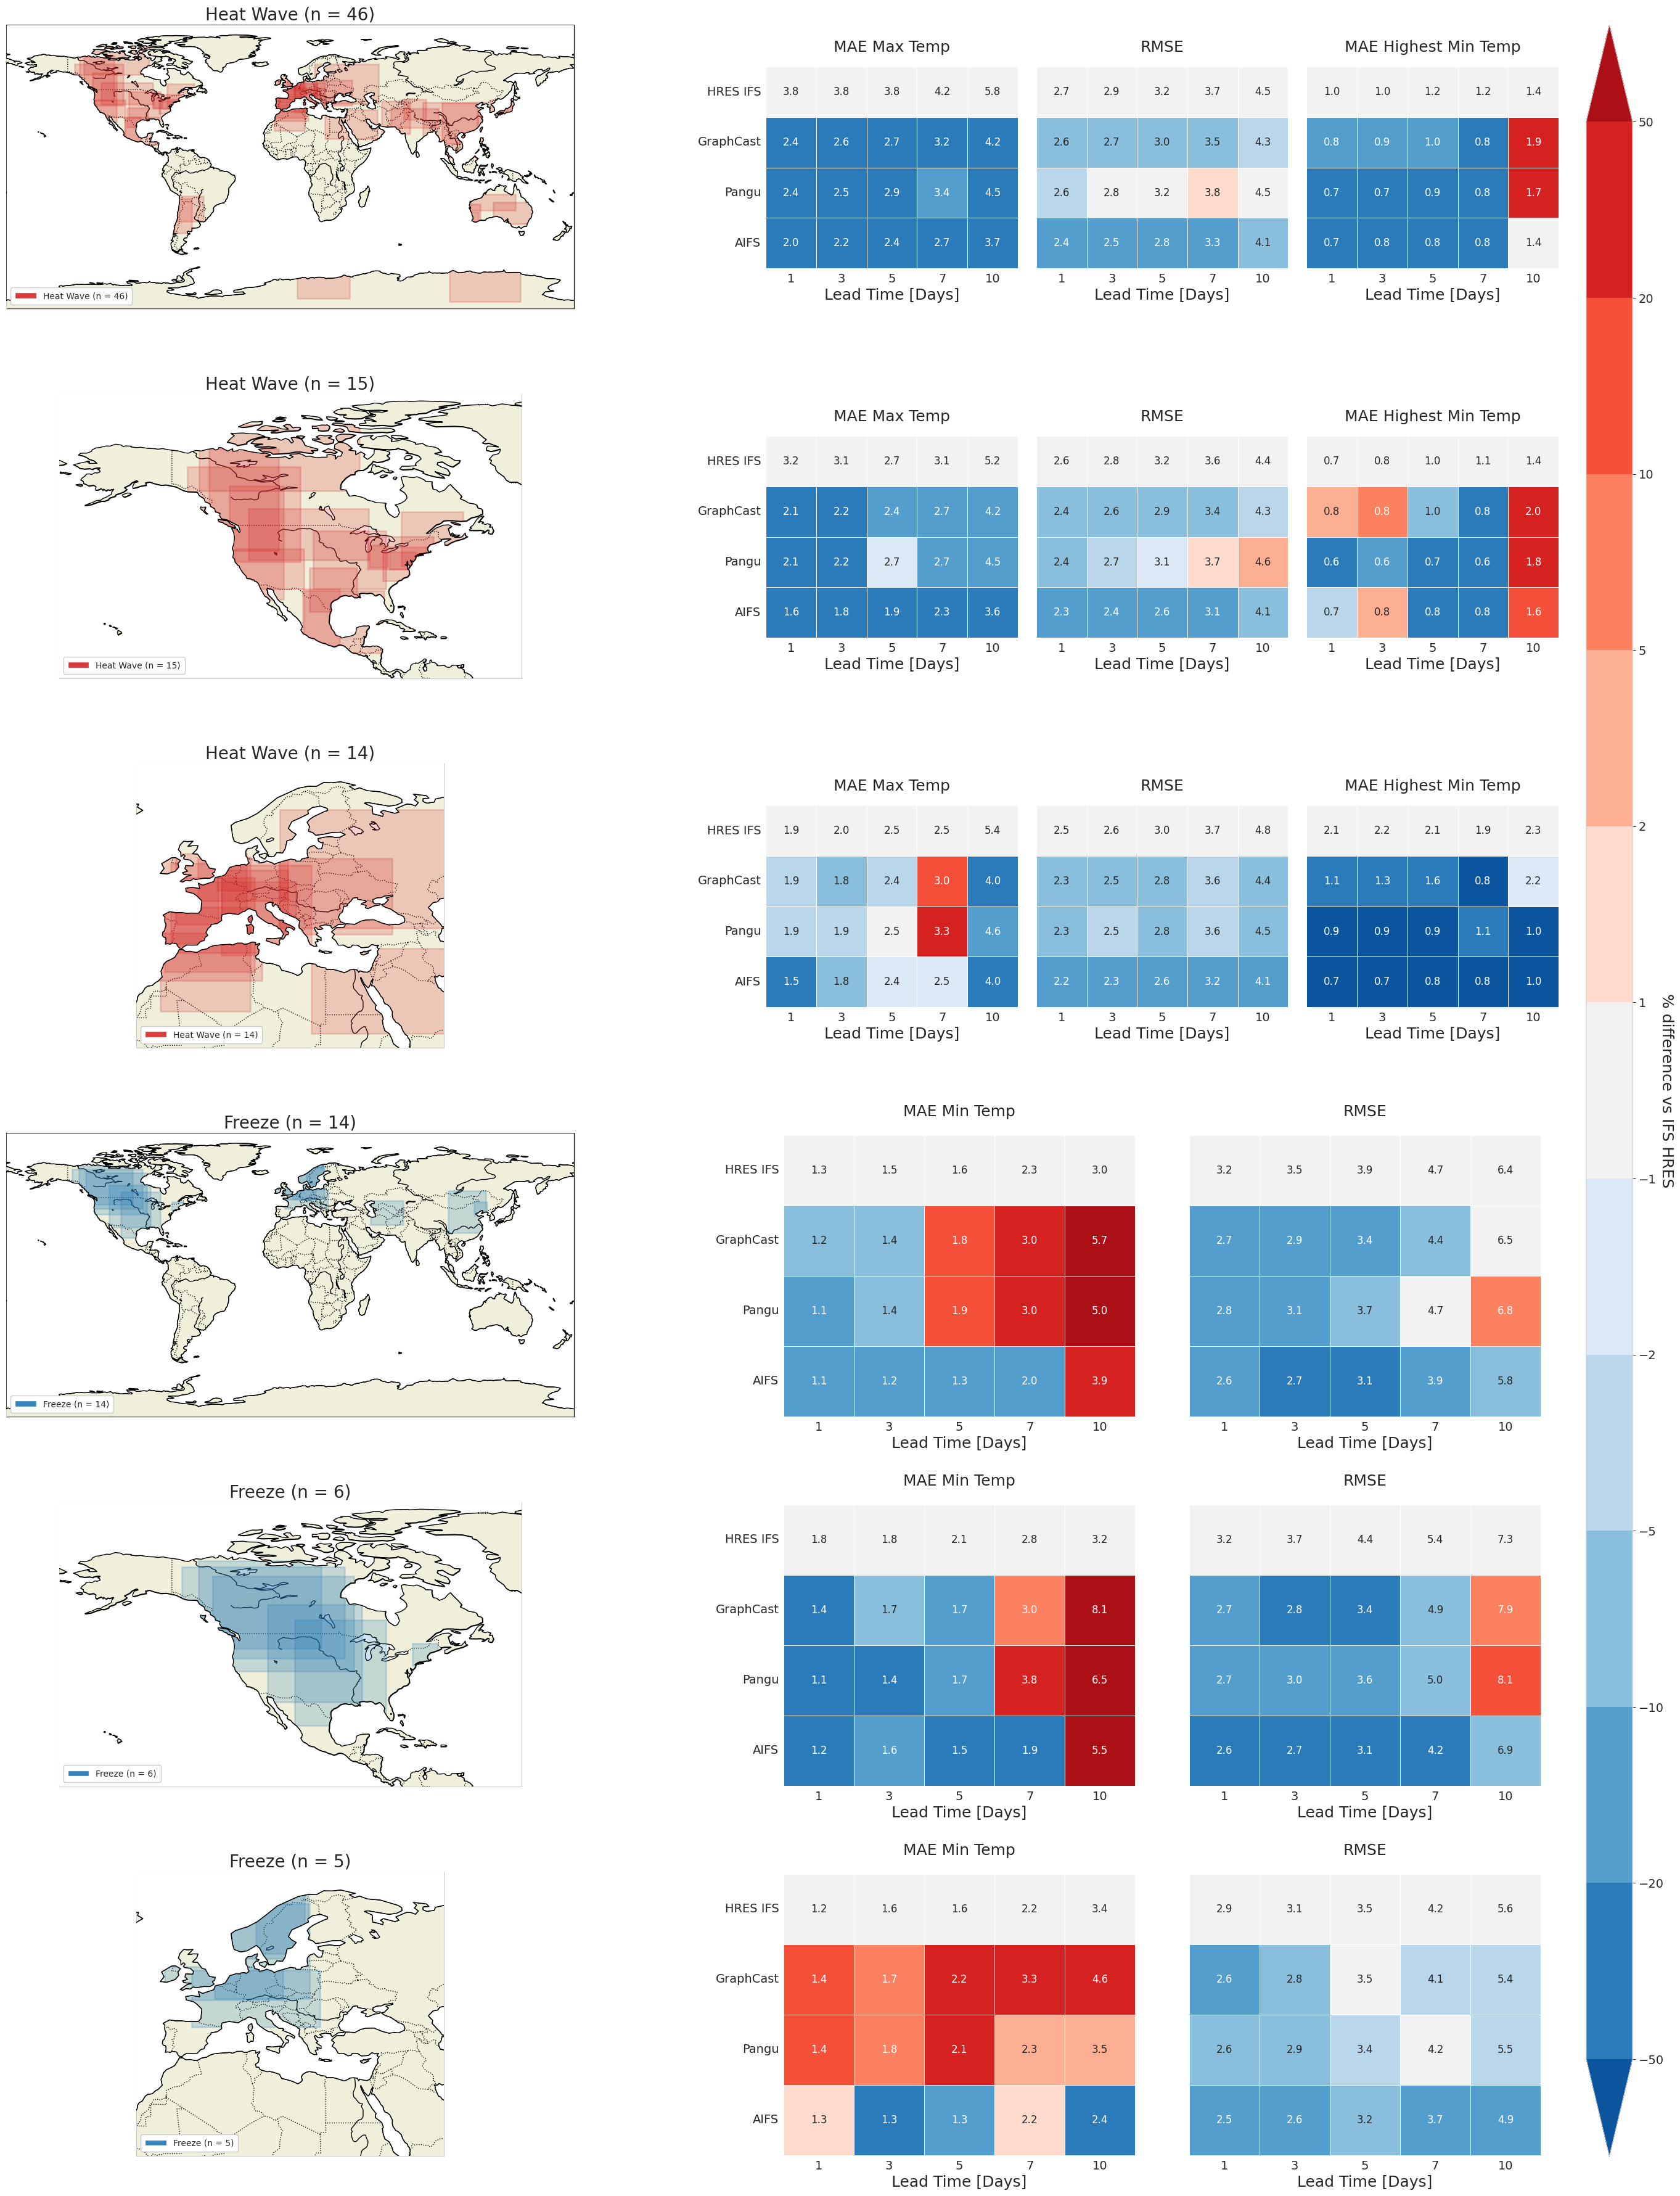

In [21]:
# this is the version of the figure that shows all the regions

from matplotlib.gridspec import GridSpec

n_rows = 6
n_cols = 2
figsize = (15 * n_cols, 6 * n_rows)
print(figsize)

# Create figure first
fig = plt.figure(figsize=figsize)

# Use GridSpec for better control over subplot sizes, especially with mixed cartopy/regular subplots
# Make column 2 wider for line plots (width_ratios: col0, col1, col2)
# Use negative hspace to compress vertical spacing (negative values allow overlap)
gs = GridSpec(n_rows, n_cols, figure=fig, 
              left=0.05, right=0.95, top=0.98, bottom=0.02,
              wspace=0.1, hspace=0.3,  
              width_ratios=[1, 1])  # Make column 2 (index 2) 1.5x wider

# Create a grid of subplots - specify which ones should use cartopy
# Example: cartopy_subplots = [(0, 0), (1, 0)] means rows 0,1 in column 0 use cartopy
# You can modify this list to specify which subplots need cartopy projections
cartopy_subplots = [(0,0), (1,0), (2,0), (3,0), (4,0), (5,0)]  # Add tuples like (row, col) for subplots that need cartopy

# Create all subplots
axs = []
for i in range(n_rows):
    row = []
    for j in range(n_cols):
        if (i, j) in cartopy_subplots:
            # Create cartopy subplot
            ax = fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())
        else:
            # Create regular matplotlib subplot
            ax = fig.add_subplot(gs[i, j])
        row.append(ax)
    axs.append(row)

# Convert to numpy array for easier indexing (matching plt.subplots behavior)
axs = np.array(axs)

# the left hand column of figure one shows all of the cases for each event type
# plot the cases for each event type
print("plotting the cases for each event type")
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="heat_wave",
    fill_boxes=True,
    ax=axs[0, 0],
)

# plot the cases for north america
plot_utils.plot_all_cases(ewb_cases, event_type='heat_wave', bounding_box=na_bounding_box, 
               fill_boxes=True, ax=axs[1, 0])

# plot the cases for europe
plot_utils.plot_all_cases(ewb_cases, event_type='heat_wave', bounding_box=eu_bounding_box, 
               fill_boxes=True, ax=axs[2, 0])


# do the same for the freeze cases
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="freeze",
    fill_boxes=True,
    ax=axs[3, 0],
)

plot_utils.plot_all_cases(
    ewb_cases,
    event_type="freeze",
    bounding_box=na_bounding_box,
    fill_boxes=True,
    ax=axs[4, 0],
)

plot_utils.plot_all_cases(
    ewb_cases,
    event_type="freeze",
    bounding_box=eu_bounding_box,
    fill_boxes=True,
    ax=axs[5, 0],
)


heat_settings = {}
heat_settings["subplot_titles"] = heat_display_str
heat_settings["metric_str"] = heat_metric_str
heat_settings["lead_time_days"] = lead_time_days
heat_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]

freeze_settings = {}
freeze_settings["subplot_titles"] = freeze_display_str
freeze_settings["metric_str"] = freeze_metric_str
freeze_settings["lead_time_days"] = lead_time_days
freeze_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]

# second column of figure 2 shows the scorecard
scorecard_mappable = plot_utils.plot_heatmap(
    global_rel_heat_error,
    global_heat_error,
    heat_settings,
    ax=axs[0, 1],
    return_mappable=True,
)

plot_utils.plot_heatmap(
    na_rel_heat_error,
    na_heat_error,
    heat_settings,
    ax=axs[1, 1],
)

plot_utils.plot_heatmap(
    eu_rel_heat_error,
    eu_heat_error,
    heat_settings,
    ax=axs[2, 1],)

plot_utils.plot_heatmap(
    global_rel_freeze_error,
    global_freeze_error,
    freeze_settings,
    ax=axs[3, 1],
)

plot_utils.plot_heatmap(
    na_rel_freeze_error,
    na_freeze_error,
    freeze_settings,
    ax=axs[4, 1],
)

plot_utils.plot_heatmap(
    eu_rel_freeze_error,
    eu_freeze_error,
    freeze_settings,
    ax=axs[5, 1],
)

plot_utils.add_scorecard_colorbar_right(
    fig,
    scorecard_mappable,
    [axs[i, 1] for i in range(6)],
    n_subplots=6,
)

fig.savefig(basepath + "graphics/paper/figure2a.png", dpi=300)

In [22]:
# load ERA5 so we can plot individual cases
era5 = ewb.defaults.era5_heatwave_target.open_and_maybe_preprocess_data_from_source()
era5 = era5.rename({'time': 'valid_time'})
temp_climatology_ds = xr.open_zarr('gs://extremeweatherbench/datasets/surface_air_temperature_1990_2019_climatology.zarr/')
temp_climatology_ds = temp_climatology_ds.sel(quantile=0.85)

(26, 36)
plotting the cases for each event type


ValueError: All-NaN slice encountered

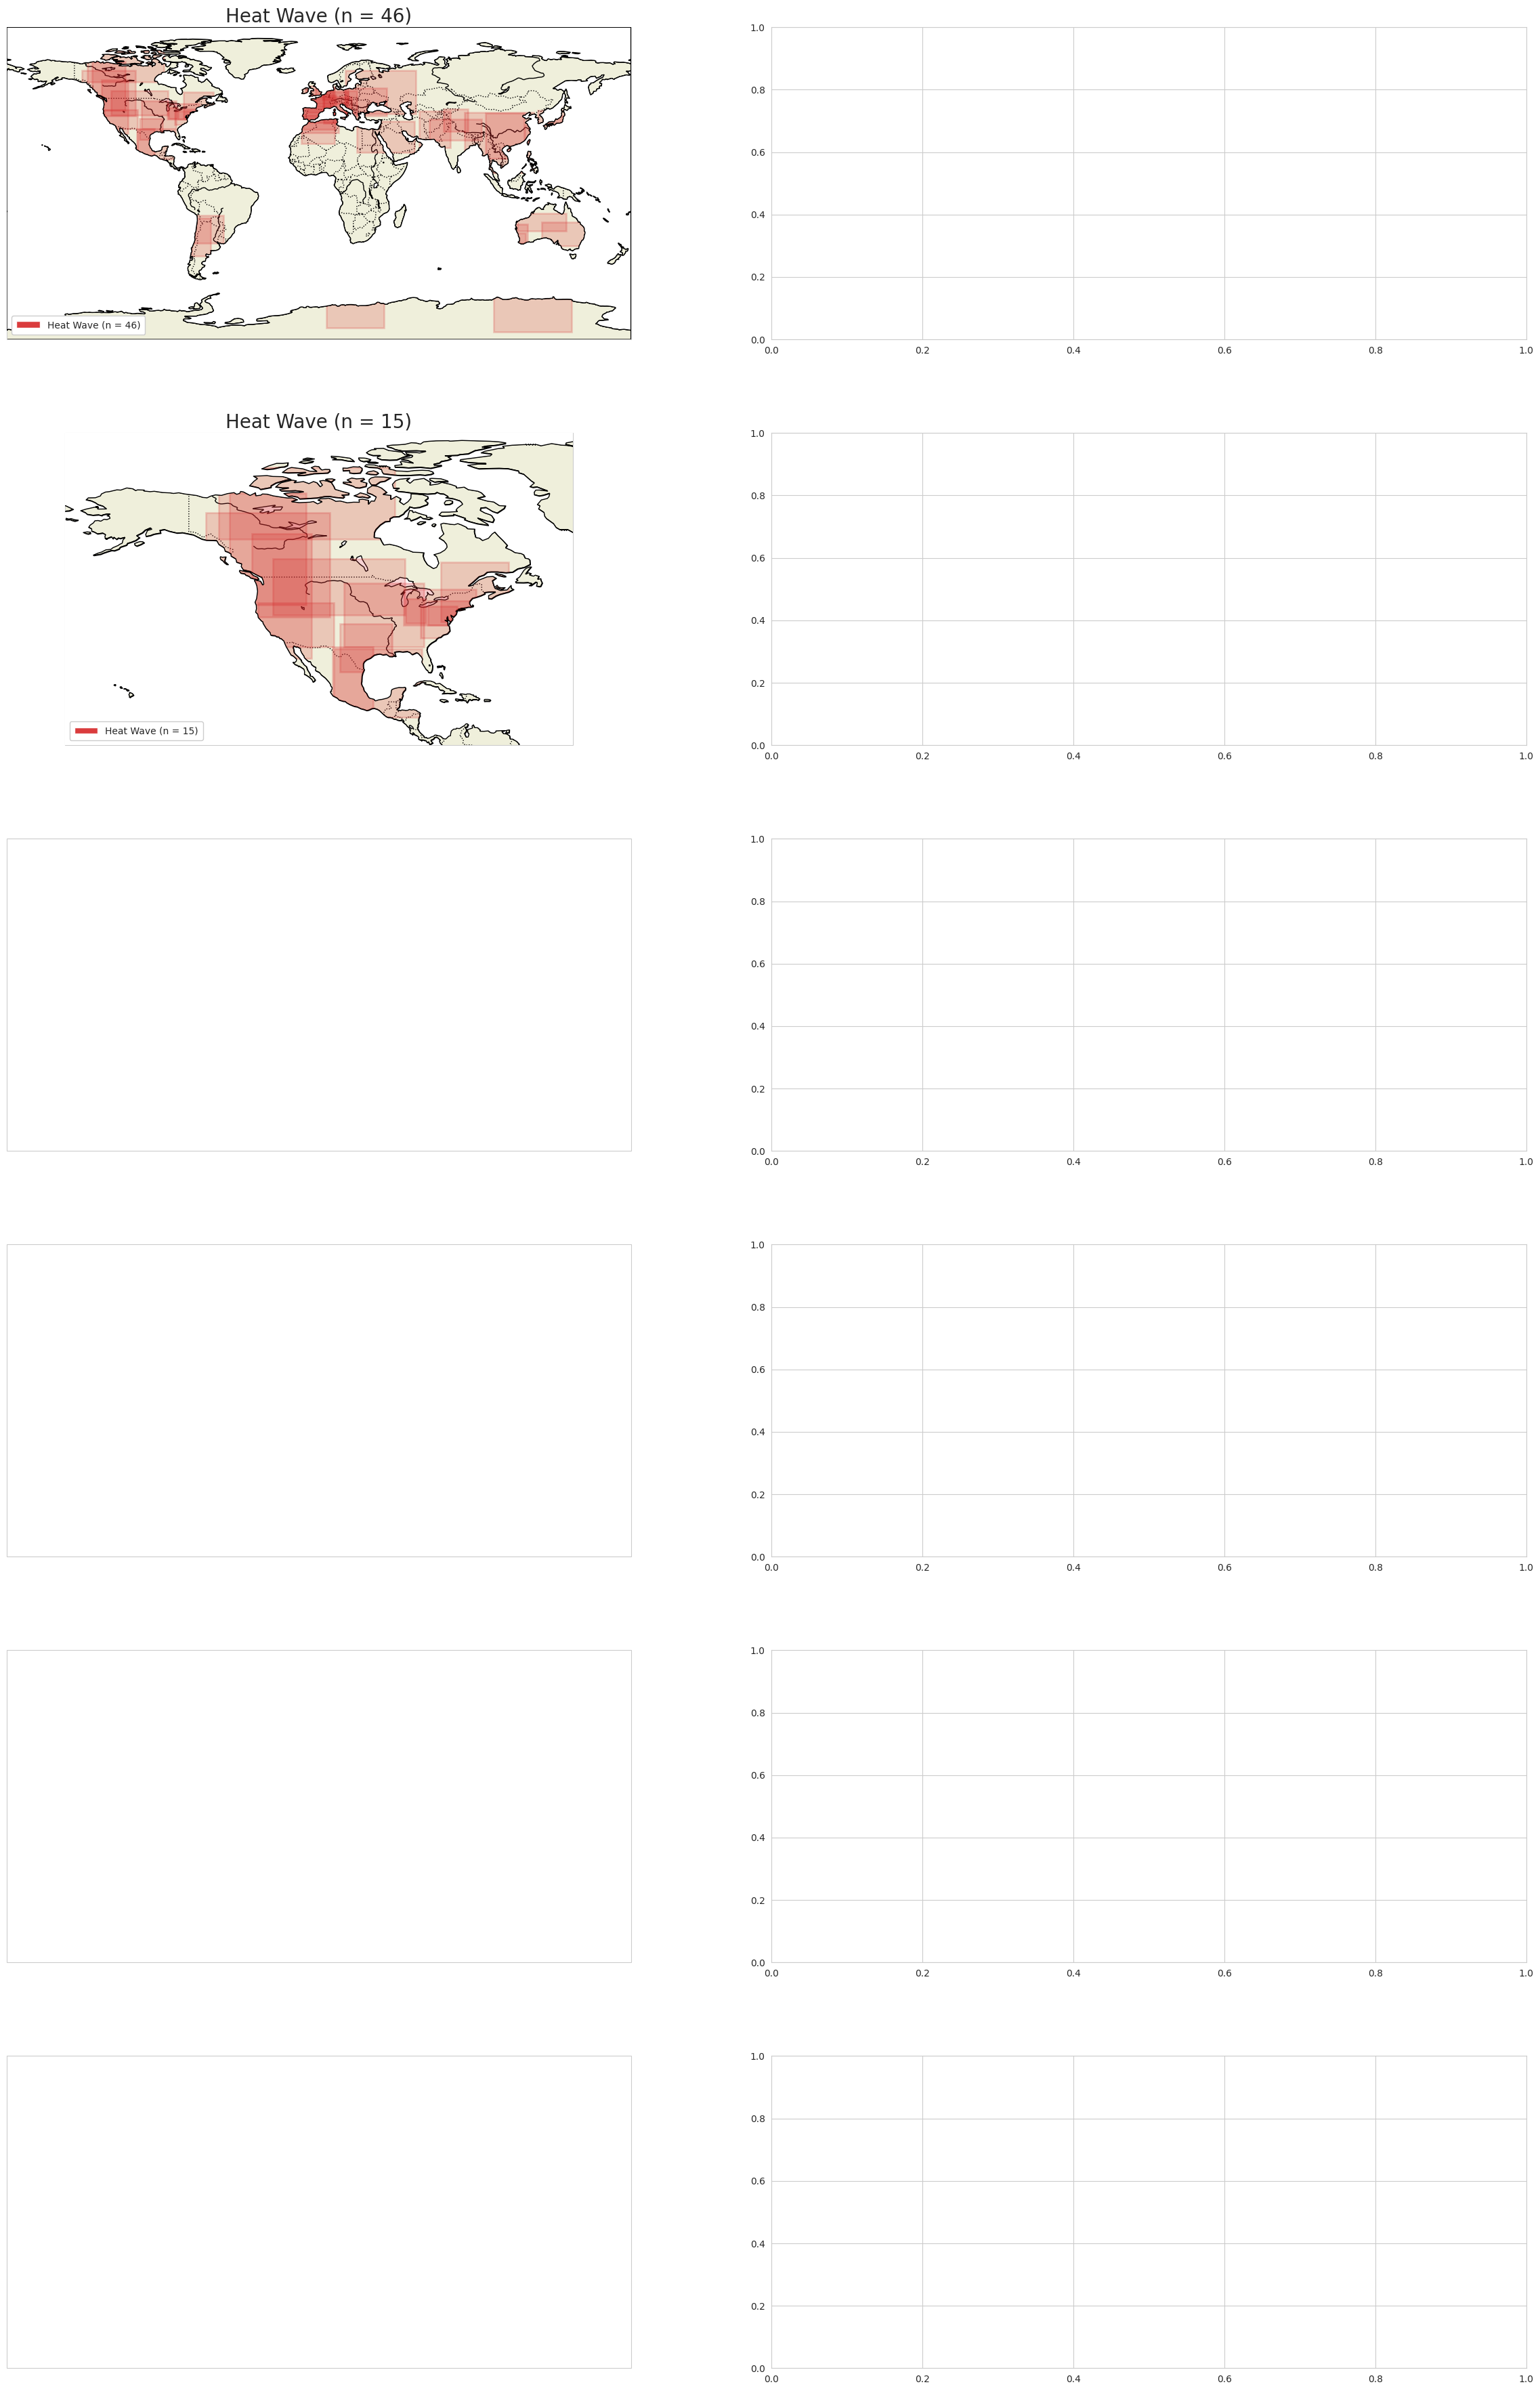

In [24]:
# this is the version of the figure that only shows some regions and then dives into 
# some case studies

from matplotlib.gridspec import GridSpec

n_rows = 6
n_cols = 2
figsize = (13 * n_cols, 6 * n_rows)
print(figsize)

# Create figure first
fig = plt.figure(figsize=figsize)

# Use GridSpec for better control over subplot sizes, especially with mixed cartopy/regular subplots
# Make column 2 wider for line plots (width_ratios: col0, col1, col2)
# Use negative hspace to compress vertical spacing (negative values allow overlap)
gs = GridSpec(n_rows, n_cols, figure=fig, 
              left=0.05, right=0.95, top=0.98, bottom=0.02,
              wspace=0.1, hspace=0.3,  
              width_ratios=[1, 1])  # Make column 2 (index 2) 1.5x wider

# Create a grid of subplots - specify which ones should use cartopy
# Example: cartopy_subplots = [(0, 0), (1, 0)] means rows 0,1 in column 0 use cartopy
# You can modify this list to specify which subplots need cartopy projections
cartopy_subplots = [(0,0), (1,0), (2,0), (3,0), (4,0), (5,0)]  # Add tuples like (row, col) for subplots that need cartopy

# Create all subplots
axs = []
for i in range(n_rows):
    row = []
    for j in range(n_cols):
        if (i, j) in cartopy_subplots:
            # Create cartopy subplot
            ax = fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())
        else:
            # Create regular matplotlib subplot
            ax = fig.add_subplot(gs[i, j])
        row.append(ax)
    axs.append(row)

# Convert to numpy array for easier indexing (matching plt.subplots behavior)
axs = np.array(axs)

# the left hand column of figure one shows all of the cases for each event type
# plot the cases for each event type
print("plotting the cases for each event type")
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="heat_wave",
    fill_boxes=True,
    ax=axs[0, 0],
)

# plot the cases for north america
plot_utils.plot_all_cases(ewb_cases, 
    event_type='heat_wave', bounding_box=na_bounding_box, 
    fill_boxes=True, ax=axs[1, 0])

# plot our specific heat case
heatwave_dataset = heat_freeze_utils.generate_heatwave_dataset(era5, temp_climatology_ds, my_heat_case)
heat_freeze_utils.plot_heatwave_case(heatwave_dataset, my_heat_case, ax=axs[2, 0])

# do the same for the freeze cases
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="freeze",
    fill_boxes=True,
    ax=axs[3, 0],
)

plot_utils.plot_all_cases(
    ewb_cases,
    event_type="freeze",
    bounding_box=eu_bounding_box,
    fill_boxes=True,
    ax=axs[4, 0],
)

# plot our specific freeze case
freeze_dataset = heat_freeze_utils.generate_freeze_dataset(era5, temp_climatology_ds, my_freeze_case)
heat_freeze_utils.plot_freeze_case(freeze_dataset, my_freeze_case, ax=axs[5, 0])

heat_settings = {}
heat_settings["subplot_titles"] = heat_display_str
heat_settings["metric_str"] = heat_metric_str
heat_settings["lead_time_days"] = lead_time_days
heat_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]

freeze_settings = {}
freeze_settings["subplot_titles"] = freeze_display_str
freeze_settings["metric_str"] = freeze_metric_str
freeze_settings["lead_time_days"] = lead_time_days
freeze_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]

# second column of figure 2 shows the scorecard
scorecard_mappable = plot_utils.plot_heatmap(
    global_rel_heat_error,
    global_heat_error,
    heat_settings,
    ax=axs[0, 1],
    return_mappable=True,
)

plot_utils.plot_heatmap(
    na_rel_heat_error,
    na_heat_error,
    heat_settings,
    ax=axs[1, 1],
)

plot_utils.plot_heatmap(
    heat_case_rel_error,
    heat_case_error,
    heat_settings,
    ax=axs[2, 1],
)

plot_utils.plot_heatmap(
    global_rel_freeze_error,
    global_freeze_error,
    freeze_settings,
    ax=axs[3, 1],
)

plot_utils.plot_heatmap(
    eu_rel_freeze_error,
    eu_freeze_error,
    freeze_settings,
    ax=axs[4, 1],
)

plot_utils.plot_heatmap(
    freeze_case_rel_error,
    freeze_case_error,
    freeze_settings,
    ax=axs[5, 1],
)

plot_utils.add_scorecard_colorbar_right(
    fig,
    scorecard_mappable,
    [axs[i, 1] for i in range(6)],
    n_subplots=6,
)

fig.savefig(basepath + "graphics/paper/figure2b.png", dpi=300)

# break heat and freeze into two figures

(18, 12)
plotting the cases for each event type


2026-04-11 14:20:23,868 plot_temperature_events INFO Opening ERA5 for 2021-06-20 to 2021-07-03 ...
2026-04-11 14:20:24,187 plot_temperature_events INFO   Subset: {'time': 56, 'latitude': 105, 'longitude': 125}
2026-04-11 14:20:24,188 plot_temperature_events INFO Loading q=0.85 climatology (op=>)...
2026-04-11 14:20:24,516 plot_temperature_events INFO Computing 6-hourly exceedance...
2026-04-11 14:20:24,559 plot_temperature_events INFO Building land mask...
2026-04-11 14:20:27,462 plot_temperature_events INFO Computing max consecutive days...


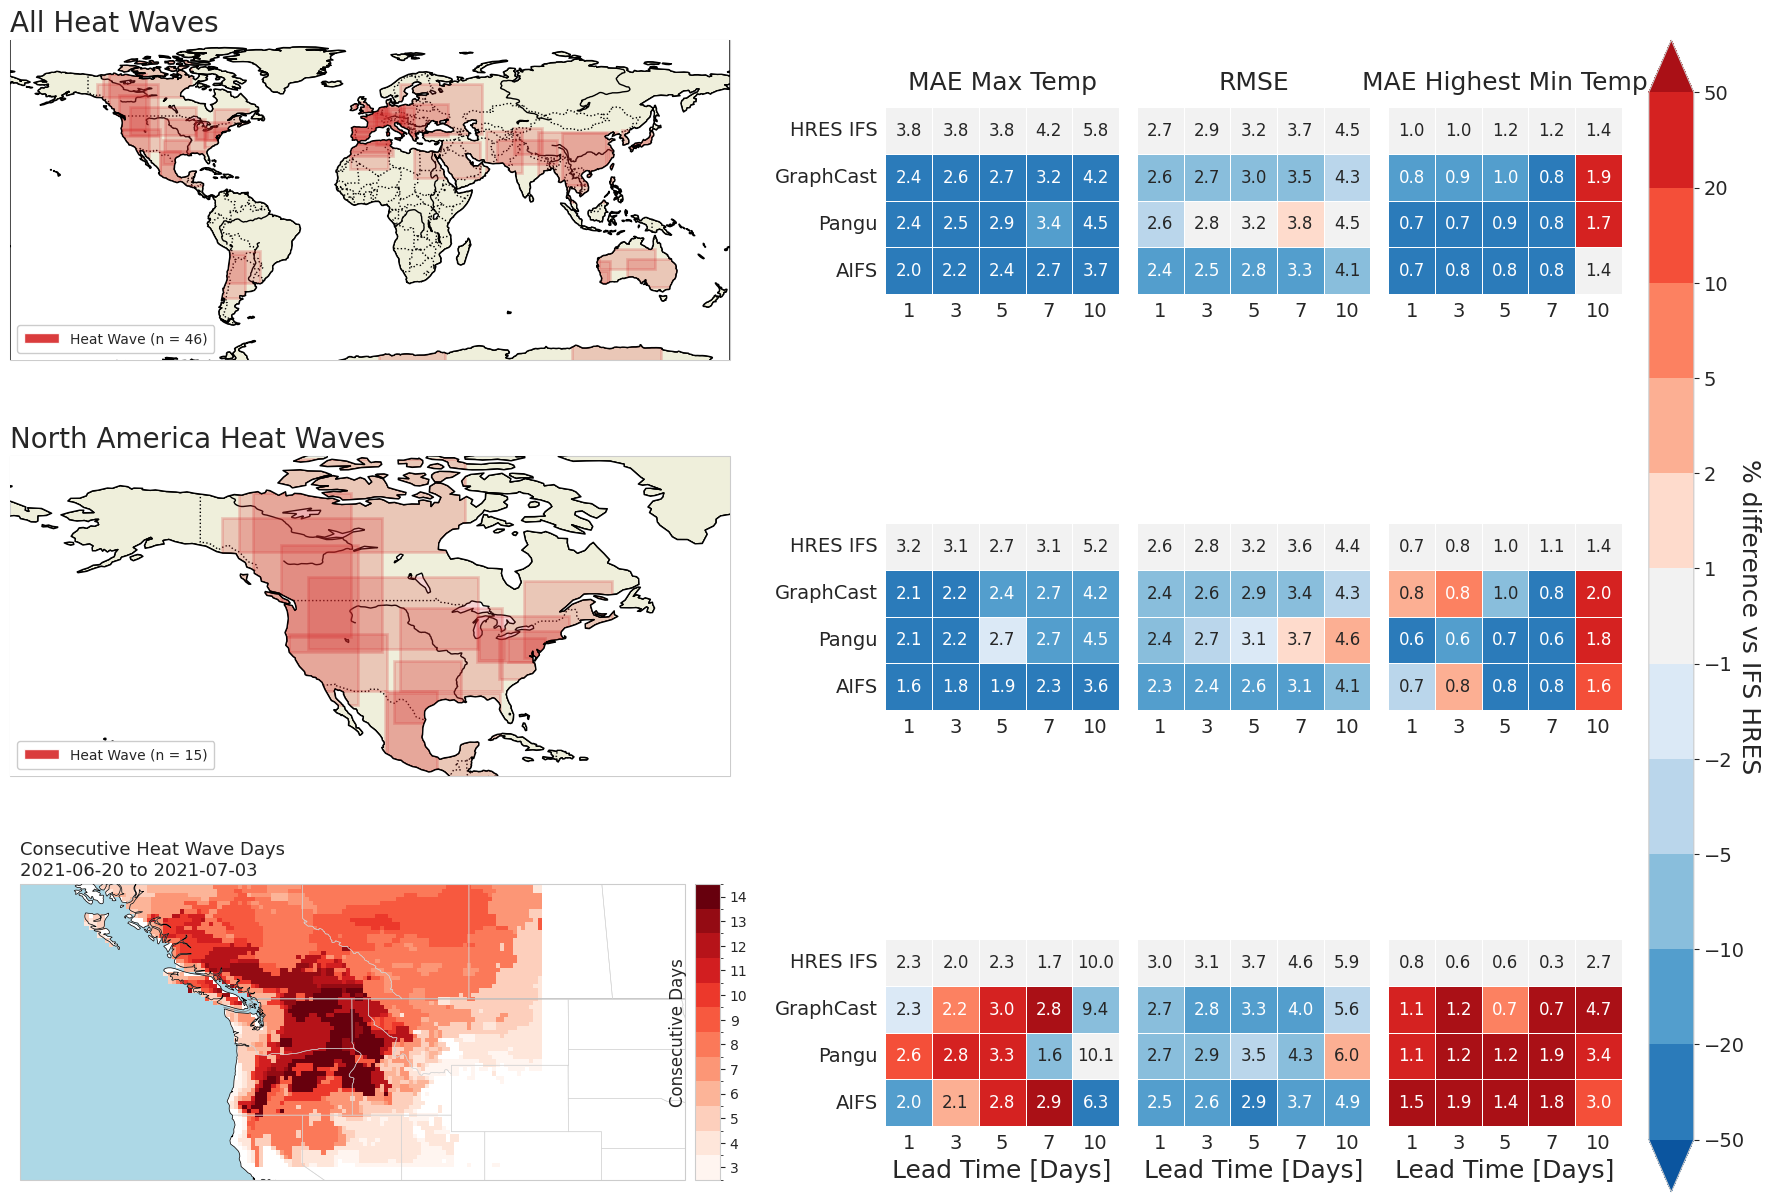

In [25]:
# this is the version of the figure that only shows some regions and then dives into 
# some case studies

from matplotlib.gridspec import GridSpec

n_rows = 3
n_cols = 2
figsize = (9 * n_cols, 4 * n_rows)
print(figsize)

# Create figure first
fig = plt.figure(figsize=figsize)

# Use GridSpec for better control over subplot sizes, especially with mixed cartopy/regular subplots
# Make column 2 wider for line plots (width_ratios: col0, col1, col2)
# Use negative hspace to compress vertical spacing (negative values allow overlap)
gs = GridSpec(n_rows, n_cols, figure=fig, 
              left=0.05, right=0.95, top=0.98, bottom=0.02,
              wspace=0.2, hspace=0.3,  
              width_ratios=[1, 1])  # Make column 2 (index 2) 1.5x wider

# Create a grid of subplots - specify which ones should use cartopy
# Example: cartopy_subplots = [(0, 0), (1, 0)] means rows 0,1 in column 0 use cartopy
# You can modify this list to specify which subplots need cartopy projections
cartopy_subplots = [(0,0), (1,0), (2,0)]

# Create all subplots
axs = []
for i in range(n_rows):
    row = []
    for j in range(n_cols):
        if (i, j) in cartopy_subplots:
            # Create cartopy subplot
            ax = fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())
        else:
            # Create regular matplotlib subplot
            ax = fig.add_subplot(gs[i, j])
        row.append(ax)
    axs.append(row)

# Convert to numpy array for easier indexing (matching plt.subplots behavior)
axs = np.array(axs)

def generate_extent(center_point, zoom, aspect_ratio, out_crs=ccrs.Mercator()):
    """Generate extent from central location and zoom level.

    Args:
        center_point (tuple): center of the map as (longitude, latitude)
        zoom (float): zoom level [0 to 10]
        aspect_ratio (tuple): aspect ratio (width, height)
        out_crs (cartopy.crs): output CRS for extent values.

    Returns:
        tuple: (lon_min, lon_max, lat_min, lat_max)
    """
    mercator_crs = ccrs.Mercator()
    zoom_coefficient = 2
    lon_min, lon_max = (
        center_point[0] - (zoom_coefficient * zoom),
        center_point[0] + (zoom_coefficient * zoom),
    )
    c_mercator = mercator_crs.transform_point(
        *center_point, src_crs=ccrs.Mercator()
    )
    lon_min = mercator_crs.transform_point(
        lon_min, center_point[1], src_crs=ccrs.Mercator()
    )[0]
    lon_max = mercator_crs.transform_point(
        lon_max, center_point[1], src_crs=ccrs.Mercator()
    )[0]
    lon_distance = lon_max - lon_min
    lat_distance = lon_distance * aspect_ratio[1] / aspect_ratio[0]
    lat_max = c_mercator[1] + lat_distance / 2
    lat_min = c_mercator[1] - lat_distance / 2
    if out_crs != ccrs.Mercator():
        lon_min, lat_min = out_crs.transform_point(
            lon_min, lat_min, src_crs=out_crs
        )
        lon_max, lat_max = out_crs.transform_point(
            lon_max, lat_max, src_crs=out_crs
        )
    return lon_min, lon_max, lat_min, lat_max


# Approximate aspect ratio of each left-column cell (width : height)
cell_aspect = (9, 4)

# Row 0: near-global view centred on the tropics
global_extent = generate_extent(
    center_point=(0, 7), zoom=90, aspect_ratio=cell_aspect,
)
# Row 1: North America
na_extent = generate_extent(
    center_point=(-108, 46), zoom=35, aspect_ratio=cell_aspect,
)
# Row 2: Pacific Northwest (2021 heatwave, case 1)
# Derive extent from the actual case bounding box (lat 39-65,
# lon -136.75 to -105.75) so the full case area is shown.
_case_bounds = my_heat_case.location.as_geopandas().total_bounds
_cb_lon_min, _cb_lat_min, _cb_lon_max, _cb_lat_max = _case_bounds
_margin = 2.0
_lat_center = (_cb_lat_min + _cb_lat_max) / 2
_lat_span = (_cb_lat_max - _cb_lat_min) + 2 * _margin
_lon_span = _lat_span * cell_aspect[0] / cell_aspect[1]
_lon_center = (_cb_lon_min + _cb_lon_max) / 2
pnw_extent = (
    _lon_center - _lon_span / 2,
    _lon_center + _lon_span / 2,
    _lat_center - _lat_span / 2,
    _lat_center + _lat_span / 2,
)

# the left hand column of figure one shows all of the cases for each event type
# plot the cases for each event type
print("plotting the cases for each event type")
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="heat_wave",
    fill_boxes=True,
    ax=axs[0, 0],
    title='All Heat Waves',
    title_loc='left',
)
# override set_global() with the generated extent
axs[0, 0].set_extent(list(global_extent), crs=ccrs.PlateCarree())

# plot the cases for north america
plot_utils.plot_all_cases(
    ewb_cases,
    event_type='heat_wave',
    bounding_box=list(na_extent),
    fill_boxes=True,
    ax=axs[1, 0],
    title='North America Heat Waves',
    title_loc='left',
)

# plot our specific heat case - consecutive days above q85 climatology
import sys
import importlib
sys.path.insert(0, str(Path.home() / "ExtremeWeatherBench" / "data_prep"))
import plot_temperature_events
importlib.reload(plot_temperature_events)
from plot_temperature_events import compute_consecutive_field, plot_consecutive_map
consec, lats, lons = compute_consecutive_field(my_heat_case)
plot_consecutive_map(
    consec, lats, lons,
    event_type=my_heat_case.event_type,
    title=(
        f"Consecutive Heat Wave Days\n"
        f"{str(my_heat_case.start_date.date())} to "
        f"{str(my_heat_case.end_date.date())}"
    ),
    ax=axs[2, 0],
    extent=pnw_extent,
)

heat_settings = {}
heat_settings["subplot_titles"] = heat_display_str
heat_settings["metric_str"] = heat_metric_str
heat_settings["lead_time_days"] = lead_time_days
heat_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]



# second column of figure 2 shows the scorecard
scorecard_mappable = plot_utils.plot_heatmap(
    global_rel_heat_error,
    global_heat_error,
    heat_settings,
    ax=axs[0, 1],
    return_mappable=True,
    show_titles=True,
    show_xlabel=False,
)

plot_utils.plot_heatmap(
    na_rel_heat_error,
    na_heat_error,
    heat_settings,
    ax=axs[1, 1],
    show_titles=False,
    show_xlabel=False,
)

plot_utils.plot_heatmap(
    heat_case_rel_error,
    heat_case_error,
    heat_settings,
    ax=axs[2, 1],
    show_titles=False,
    show_xlabel=True,
)

plot_utils.add_scorecard_colorbar_right(
    fig,
    scorecard_mappable,
    [axs[i, 1] for i in range(3)],
    n_subplots=3,
)

# Match axes border style across all map panels to the bottom-left reference
ref_spines = axs[2, 0].spines
for i, j in cartopy_subplots:
    for key, spine in axs[i, j].spines.items():
        if key in ref_spines:
            spine.set_linewidth(ref_spines[key].get_linewidth())
            spine.set_edgecolor(ref_spines[key].get_edgecolor())

# Force layout calculation, then manually center each map within its cell
fig.canvas.draw()
for i, j in cartopy_subplots:
    ax = axs[i, j]
    cell_pos = gs[i, j].get_position(fig)
    ax_pos = ax.get_position()
    if ax_pos.width < cell_pos.width:
        new_x0 = cell_pos.x0 + (cell_pos.width - ax_pos.width) / 2
        ax.set_position([new_x0, ax_pos.y0, ax_pos.width, ax_pos.height])

fig.savefig(basepath + "graphics/paper/figure2_heat.png", dpi=300)

2026-04-11 14:20:32,273 plot_temperature_events INFO Opening ERA5 for 2022-12-10 to 2022-12-20 ...


(18, 12)
plotting the cases for each event type


2026-04-11 14:20:32,553 plot_temperature_events INFO   Subset: {'time': 44, 'latitude': 29, 'longitude': 101}
2026-04-11 14:20:32,553 plot_temperature_events INFO Loading q=0.15 climatology (op=<)...
2026-04-11 14:20:32,814 plot_temperature_events INFO Computing 6-hourly exceedance...
2026-04-11 14:20:32,827 plot_temperature_events INFO Building land mask...
2026-04-11 14:20:35,218 plot_temperature_events INFO Computing max consecutive days...


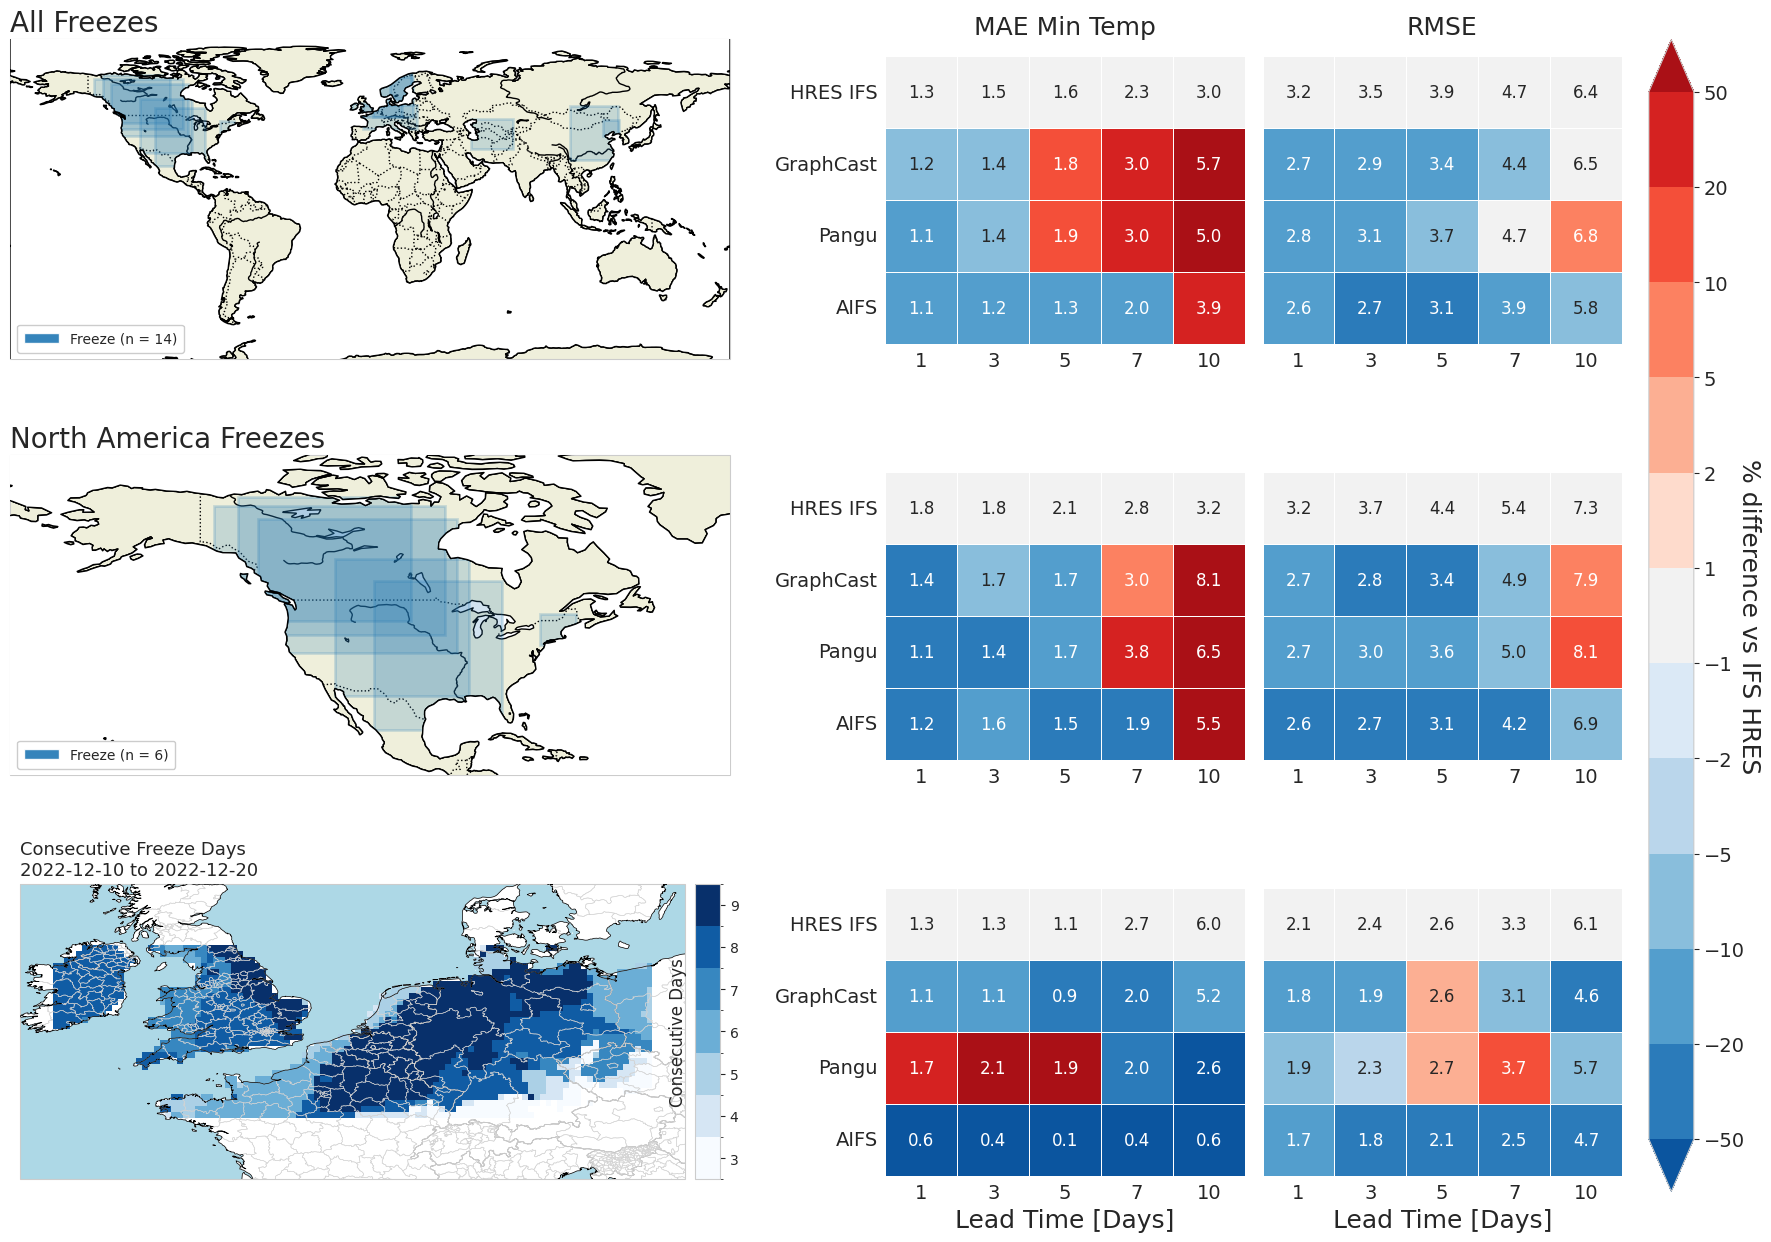

In [26]:
# this is the version of the figure that only shows some regions and then dives into 
# some case studies

from matplotlib.gridspec import GridSpec

n_rows = 3
n_cols = 2
figsize = (9 * n_cols, 4 * n_rows)
print(figsize)

# Create figure first
fig = plt.figure(figsize=figsize)

# Use GridSpec for better control over subplot sizes, especially with mixed cartopy/regular subplots
# Make column 2 wider for line plots (width_ratios: col0, col1, col2)
# Use negative hspace to compress vertical spacing (negative values allow overlap)
gs = GridSpec(n_rows, n_cols, figure=fig, 
              left=0.05, right=0.95, top=0.98, bottom=0.02,
              wspace=0.2, hspace=0.3,  
              width_ratios=[1, 1])  # Make column 2 (index 2) 1.5x wider

# Create a grid of subplots - specify which ones should use cartopy
# Example: cartopy_subplots = [(0, 0), (1, 0)] means rows 0,1 in column 0 use cartopy
# You can modify this list to specify which subplots need cartopy projections
cartopy_subplots = [(0,0), (1,0), (2,0)]

# Create all subplots
axs = []
for i in range(n_rows):
    row = []
    for j in range(n_cols):
        if (i, j) in cartopy_subplots:
            # Create cartopy subplot
            ax = fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())
        else:
            # Create regular matplotlib subplot
            ax = fig.add_subplot(gs[i, j])
        row.append(ax)
    axs.append(row)

# Convert to numpy array for easier indexing (matching plt.subplots behavior)
axs = np.array(axs)

def generate_extent(center_point, zoom, aspect_ratio, out_crs=ccrs.Mercator()):
    """Generate extent from central location and zoom level.

    Args:
        center_point (tuple): center of the map as (longitude, latitude)
        zoom (float): zoom level [0 to 10]
        aspect_ratio (tuple): aspect ratio (width, height)
        out_crs (cartopy.crs): output CRS for extent values.

    Returns:
        tuple: (lon_min, lon_max, lat_min, lat_max)
    """
    mercator_crs = ccrs.Mercator()
    zoom_coefficient = 2
    lon_min, lon_max = (
        center_point[0] - (zoom_coefficient * zoom),
        center_point[0] + (zoom_coefficient * zoom),
    )
    c_mercator = mercator_crs.transform_point(
        *center_point, src_crs=ccrs.Mercator()
    )
    lon_min = mercator_crs.transform_point(
        lon_min, center_point[1], src_crs=ccrs.Mercator()
    )[0]
    lon_max = mercator_crs.transform_point(
        lon_max, center_point[1], src_crs=ccrs.Mercator()
    )[0]
    lon_distance = lon_max - lon_min
    lat_distance = lon_distance * aspect_ratio[1] / aspect_ratio[0]
    lat_max = c_mercator[1] + lat_distance / 2
    lat_min = c_mercator[1] - lat_distance / 2
    if out_crs != ccrs.Mercator():
        lon_min, lat_min = out_crs.transform_point(
            lon_min, lat_min, src_crs=out_crs
        )
        lon_max, lat_max = out_crs.transform_point(
            lon_max, lat_max, src_crs=out_crs
        )
    return lon_min, lon_max, lat_min, lat_max


# Approximate aspect ratio of each left-column cell (width : height)
cell_aspect = (9, 4)

# Row 0: near-global view centred on the tropics
global_extent = generate_extent(
    center_point=(0, 7), zoom=90, aspect_ratio=cell_aspect,
)
# Row 1: North America
na_extent = generate_extent(
    center_point=(-108, 46), zoom=35, aspect_ratio=cell_aspect,
)
# Row 2: Europe (December 2022 freeze, case 91)
eu_extent = generate_extent(
    center_point=(3.5, 51.5), zoom=7, aspect_ratio=cell_aspect,
)

# the left hand column of figure one shows all of the cases for each event type
# plot the cases for each event type
print("plotting the cases for each event type")
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="freeze",
    fill_boxes=True,
    ax=axs[0, 0],
    title='All Freezes',
    title_loc='left',
)
# override set_global() with the generated extent
axs[0, 0].set_extent(list(global_extent), crs=ccrs.PlateCarree())

# plot the cases for north america
plot_utils.plot_all_cases(
    ewb_cases,
    event_type='freeze',
    bounding_box=list(na_extent),
    fill_boxes=True,
    ax=axs[1, 0],
    title='North America Freezes',
    title_loc='left',
)

# plot our specific freeze case - consecutive days below q15 climatology
import sys
import importlib
sys.path.insert(0, str(Path.home() / "ExtremeWeatherBench" / "data_prep"))
import plot_temperature_events
importlib.reload(plot_temperature_events)
from plot_temperature_events import compute_consecutive_field, plot_consecutive_map
consec, lats, lons = compute_consecutive_field(my_freeze_case)
plot_consecutive_map(
    consec, lats, lons,
    event_type=my_freeze_case.event_type,
    title=(
        f"Consecutive Freeze Days\n"
        f"{str(my_freeze_case.start_date.date())} to "
        f"{str(my_freeze_case.end_date.date())}"
    ),
    ax=axs[2, 0],
    extent=eu_extent,
)

freeze_settings = {}
freeze_settings["subplot_titles"] = freeze_display_str
freeze_settings["metric_str"] = freeze_metric_str
freeze_settings["lead_time_days"] = lead_time_days
freeze_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]

# second column of figure 2 shows the scorecard
scorecard_mappable = plot_utils.plot_heatmap(
    global_rel_freeze_error,
    global_freeze_error,
    freeze_settings,
    ax=axs[0, 1],
    return_mappable=True,
    show_titles=True,
    show_xlabel=False,
)

plot_utils.plot_heatmap(
    na_rel_freeze_error,
    na_freeze_error,
    freeze_settings,
    ax=axs[1, 1],
    show_titles=False,
    show_xlabel=False,
)

plot_utils.plot_heatmap(
    freeze_case_rel_error,
    freeze_case_error,
    freeze_settings,
    ax=axs[2, 1],
    show_titles=False,
    show_xlabel=True,
)

plot_utils.add_scorecard_colorbar_right(
    fig,
    scorecard_mappable,
    [axs[i, 1] for i in range(3)],
    n_subplots=3,
)

# Match axes border style across all map panels to the bottom-left reference
ref_spines = axs[2, 0].spines
for i, j in cartopy_subplots:
    for key, spine in axs[i, j].spines.items():
        if key in ref_spines:
            spine.set_linewidth(ref_spines[key].get_linewidth())
            spine.set_edgecolor(ref_spines[key].get_edgecolor())

# Force layout calculation, then manually center each map within its cell
fig.canvas.draw()
for i, j in cartopy_subplots:
    ax = axs[i, j]
    cell_pos = gs[i, j].get_position(fig)
    ax_pos = ax.get_position()
    if ax_pos.width < cell_pos.width:
        new_x0 = cell_pos.x0 + (cell_pos.width - ax_pos.width) / 2
        ax.set_position([new_x0, ax_pos.y0, ax_pos.width, ax_pos.height])

fig.savefig(basepath + "graphics/paper/figure2_freeze.png", dpi=300)

(16, 9)
plotting the cases for each event type


/home/taylor/ExtremeWeatherBench/.venv/lib/python3.13/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'ls'
  result = super().contour(*args, **kwargs)


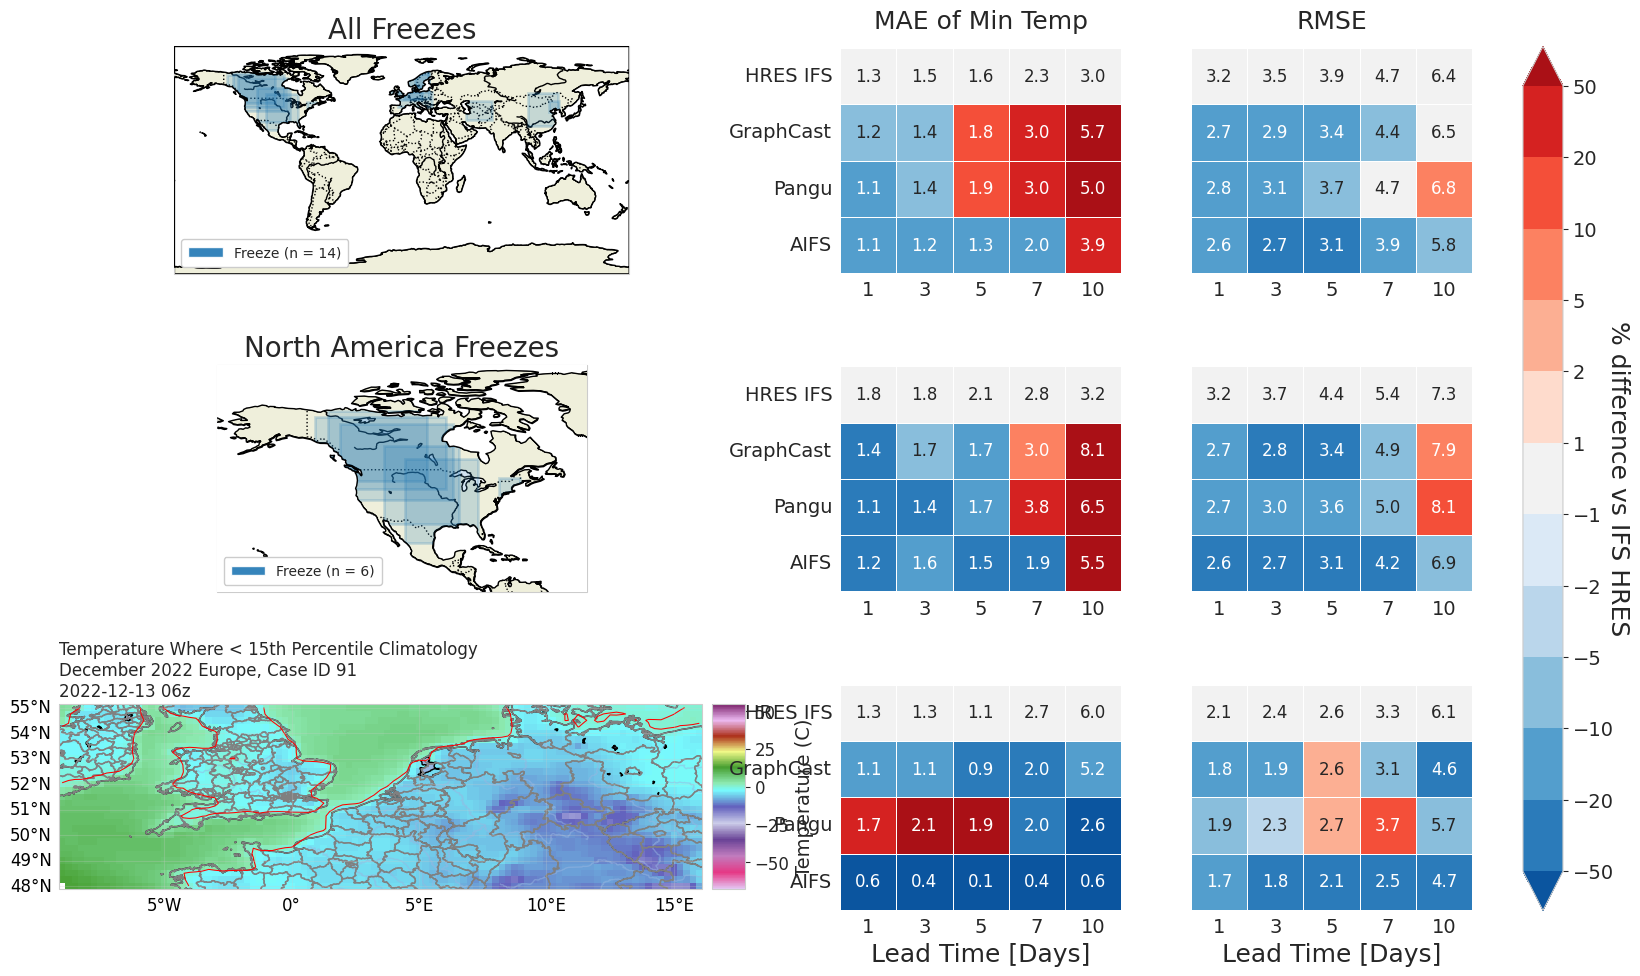

In [ ]:
# this is the version of the figure that only shows some regions and then dives into 
# some case studies

from matplotlib.gridspec import GridSpec

n_rows = 3
n_cols = 2
figsize = (8 * n_cols, 3 * n_rows)
print(figsize)

# Create figure first
fig = plt.figure(figsize=figsize)

# Use GridSpec for better control over subplot sizes, especially with mixed cartopy/regular subplots
# Make column 2 wider for line plots (width_ratios: col0, col1, col2)
# Use negative hspace to compress vertical spacing (negative values allow overlap)
gs = GridSpec(n_rows, n_cols, figure=fig, 
              left=0.05, right=0.95, top=0.98, bottom=0.02,
              wspace=0.1, hspace=0.4,  
              width_ratios=[1, 1])  # Make column 2 (index 2) 1.5x wider

# Create a grid of subplots - specify which ones should use cartopy
# Example: cartopy_subplots = [(0, 0), (1, 0)] means rows 0,1 in column 0 use cartopy
# You can modify this list to specify which subplots need cartopy projections
cartopy_subplots = [(0,0), (1,0), (2,0), (3,0), (4,0), (5,0)]  # Add tuples like (row, col) for subplots that need cartopy

# Create all subplots
axs = []
for i in range(n_rows):
    row = []
    for j in range(n_cols):
        if (i, j) in cartopy_subplots:
            # Create cartopy subplot
            ax = fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())
        else:
            # Create regular matplotlib subplot
            ax = fig.add_subplot(gs[i, j])
        row.append(ax)
    axs.append(row)

# Convert to numpy array for easier indexing (matching plt.subplots behavior)
axs = np.array(axs)

# the left hand column of figure one shows all of the cases for each event type
# plot the cases for each event type
print("plotting the cases for each event type")
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="freeze",
    fill_boxes=True,
    ax=axs[0, 0],
    title='All Freezes',
)

# plot the cases for north america
plot_utils.plot_all_cases(ewb_cases, 
    event_type='freeze', bounding_box=na_bounding_box, 
    fill_boxes=True, ax=axs[1, 0], title='North America Freezes')

# plot our specific freeze case
freeze_dataset = heat_freeze_utils.generate_freeze_dataset(era5, temp_climatology_ds, my_freeze_case)
heat_freeze_utils.plot_freeze_case(freeze_dataset, my_freeze_case, ax=axs[2, 0])

freeze_settings = {}
freeze_settings["subplot_titles"] = freeze_display_str
freeze_settings["metric_str"] = freeze_metric_str
freeze_settings["lead_time_days"] = lead_time_days
freeze_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]

# second column of figure 2 shows the scorecard
scorecard_mappable = plot_utils.plot_heatmap(
    global_rel_freeze_error,
    global_freeze_error,
    freeze_settings,
    ax=axs[0, 1],
    return_mappable=True,
    show_titles=True,
    show_xlabel=False,
)

plot_utils.plot_heatmap(
    na_rel_freeze_error,
    na_freeze_error,
    freeze_settings,
    ax=axs[1, 1],
    show_titles=False,
    show_xlabel=False,
)

plot_utils.plot_heatmap(
    freeze_case_rel_error,
    freeze_case_error,
    freeze_settings,
    ax=axs[2, 1],
    show_titles=False,
    show_xlabel=True,
)

plot_utils.add_scorecard_colorbar_right(
    fig,
    scorecard_mappable,
    [axs[i, 1] for i in range(3)],
    n_subplots=3,
)


fig.savefig(basepath + "graphics/paper/figure2_freeze.png", dpi=300)

# same figure without the subfigures for the talks

In [ ]:
# plot the cases for each event type
print("plotting the cases for each event type")
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="heat_wave",
    fill_boxes=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure2b_heat_wave.png", dpi=300, bbox_inches='tight')

# plot the cases for north america
plot_utils.plot_all_cases(ewb_cases, 
    event_type='heat_wave', bounding_box=na_bounding_box, 
    fill_boxes=True)
plt.savefig(basepath + "graphics/paper/subplots/figure2b_heat_wave_na.png", dpi=300, bbox_inches='tight')

# plot our specific heat case
heatwave_dataset = heat_freeze_utils.generate_heatwave_dataset(era5, temp_climatology_ds, my_heat_case.cases[0])
heat_freeze_utils.plot_heatwave_case(heatwave_dataset, my_heat_case.cases[0])
plt.savefig(basepath + "graphics/paper/subplots/figure2b_heat_wave_case.png", dpi=300, bbox_inches='tight')

# do the same for the freeze cases
plot_utils.plot_all_cases(
    ewb_cases,
    event_type="freeze",
    fill_boxes=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure2b_freeze.png", dpi=300, bbox_inches='tight')

plot_utils.plot_all_cases(
    ewb_cases,
    event_type="freeze",
    bounding_box=eu_bounding_box,
    fill_boxes=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure2b_freeze_eu.png", dpi=300, bbox_inches='tight')

# plot our specific freeze case
freeze_dataset = heat_freeze_utils.generate_freeze_dataset(era5, temp_climatology_ds, my_freeze_case.cases[0])
heat_freeze_utils.plot_freeze_case(freeze_dataset, my_freeze_case.cases[0])
plt.savefig(basepath + "graphics/paper/subplots/figure2b_freeze_case.png", dpi=300, bbox_inches='tight')

heat_settings = {}
heat_settings["subplot_titles"] = heat_display_str
heat_settings["metric_str"] = heat_metric_str
heat_settings["lead_time_days"] = lead_time_days
heat_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]

freeze_settings = {}
freeze_settings["subplot_titles"] = freeze_display_str
freeze_settings["metric_str"] = freeze_metric_str
freeze_settings["lead_time_days"] = lead_time_days
freeze_settings["model_order"] = ["HRES IFS", "GraphCast", "Pangu", "AIFS"]

# second column of figure 2 shows the scorecard
plot_utils.plot_heatmap(
    global_rel_heat_error,
    global_heat_error,
    heat_settings,
    show_colorbar=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure2b_heat_map.png", dpi=300, bbox_inches='tight')

plot_utils.plot_heatmap(
    na_rel_heat_error,
    na_heat_error,
    heat_settings,
    show_colorbar=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure2b_heat_map_na.png", dpi=300, bbox_inches='tight')

plot_utils.plot_heatmap(
    heat_case_rel_error,
    heat_case_error,
    heat_settings,
    show_colorbar=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure2b_heat_map_case.png", dpi=300, bbox_inches='tight')

plot_utils.plot_heatmap(
    global_rel_freeze_error,
    global_freeze_error,
    freeze_settings,
    show_colorbar=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure2b_freeze_map.png", dpi=300, bbox_inches='tight')

plot_utils.plot_heatmap(
    eu_rel_freeze_error,
    eu_freeze_error,
    freeze_settings,
    show_colorbar=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure2b_freeze_map_eu.png", dpi=300, bbox_inches='tight')
plot_utils.plot_heatmap(
    freeze_case_rel_error,
    freeze_case_error,
    freeze_settings,
    show_colorbar=True,
)
plt.savefig(basepath + "graphics/paper/subplots/figure2b_freeze_map_case.png", dpi=300, bbox_inches='tight')

